In [5]:
# Roll No: 24BAD047

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, classification_report
from imblearn.over_sampling import SMOTE

In [6]:
df = pd.read_csv(r"C:\Users\Admin\Desktop\4_sem\ML\EX_NO_6\fraud_smote.csv")

In [ ]:
X = df.drop("Fraud", axis=1)
y = df["Fraud"]

Before SMOTE:
 Fraud
0    110
1     10
Name: count, dtype: int64


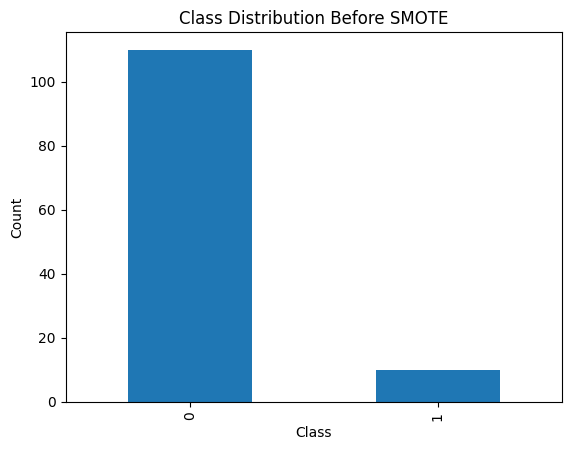

In [8]:
print("Before SMOTE:\n", y.value_counts())

plt.figure()
y.value_counts().plot(kind='bar')
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
pred_before = model.predict(X_test)

print("\nBefore SMOTE Report:\n", classification_report(y_test, pred_before))


Before SMOTE Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       0.00      0.00      0.00         2

    accuracy                           0.92        24
   macro avg       0.46      0.50      0.48        24
weighted avg       0.84      0.92      0.88        24



c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [11]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

After SMOTE:
 Fraud
1    88
0    88
Name: count, dtype: int64


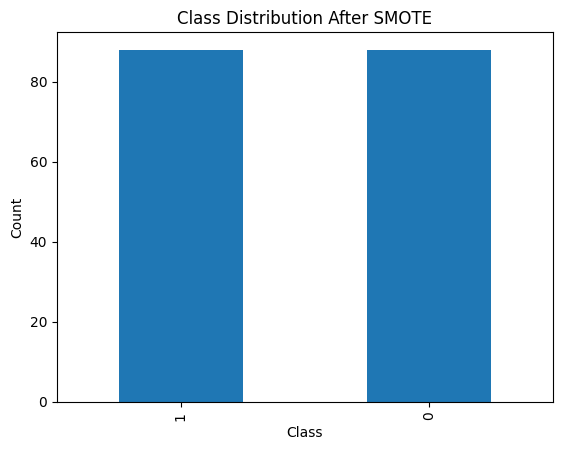

In [12]:
print("After SMOTE:\n", pd.Series(y_res).value_counts())

plt.figure()
pd.Series(y_res).value_counts().plot(kind='bar')
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [13]:
model.fit(X_res, y_res)
pred_after = model.predict(X_test)

print("\nAfter SMOTE Report:\n", classification_report(y_test, pred_after))


After SMOTE Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91        22
           1       0.00      0.00      0.00         2

    accuracy                           0.83        24
   macro avg       0.45      0.45      0.45        24
weighted avg       0.83      0.83      0.83        24



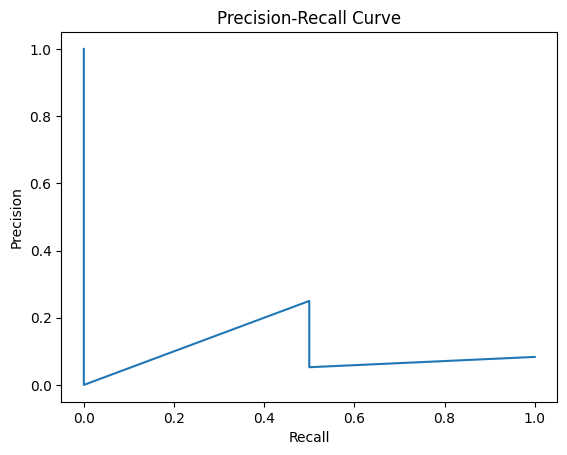

In [14]:
prob = model.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()